# IN403 – Unit 10 Lab: Production Monitoring, Alerting, and Incident Response
**Student:** Shubham Raj  
**Date:** September 2026

## Objective
Analyze production telemetry for two hospital AI systems and create an alert + response plan.

### Systems Monitored
- **No-Show Predictor** — A tabular classification model that predicts whether patients will miss scheduled appointments. The hospital uses these predictions to guide overbooking decisions, manage clinic schedules, and reduce wasted provider time.
- **Policy RAG Assistant** — An LLM-based retrieval-augmented generation system that helps clinical and administrative staff find answers to hospital policy questions. Staff submit natural-language queries, and the system retrieves relevant policy documents and generates grounded answers with source citations.

### Deliverables
1. Identify which days should trigger alerts and why
2. Create an alert dashboard table with justified thresholds
3. Draft a mini-runbook response for one critical alert
4. Recommend a remediation plan (retrain, rollback, safe-mode, re-index docs, etc.)
5. Write a Production Operations Memo (350–500 words)

In [1]:
# Imports
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1 — Load Dataset

In [2]:
# Multi-path search (works in Colab with zip upload and local VS Code)
search_paths = [
    'unit10_data',                                             # Colab after zip extraction
    'unit10_data/IN403_Unit10_Production_Monitoring_Dataset',   # nested zip
    'IN403_Unit10_Production_Monitoring_Dataset',               # local subfolder (VS Code)
    '.',                                                       # current directory
]

data_dir = None
for p in search_paths:
    if os.path.isfile(os.path.join(p, 'production_metrics_daily.csv')):
        data_dir = p
        break

# Fallback: try extracting zip if present
if data_dir is None:
    zip_file = 'IN403_Unit10_Production_Monitoring_Dataset.zip'
    if os.path.isfile(zip_file):
        import zipfile
        os.makedirs('unit10_data', exist_ok=True)
        with zipfile.ZipFile(zip_file, 'r') as z:
            z.extractall('unit10_data')
        for p in search_paths:
            if os.path.isfile(os.path.join(p, 'production_metrics_daily.csv')):
                data_dir = p
                break

if data_dir is None:
    raise FileNotFoundError('Could not locate production_metrics_daily.csv in any expected path.')

print(f'Data directory: {data_dir}')

metrics = pd.read_csv(os.path.join(data_dir, 'production_metrics_daily.csv'))
feedback = pd.read_csv(os.path.join(data_dir, 'user_feedback_log.csv'))
runbook  = open(os.path.join(data_dir, 'production_runbook.txt'), 'r', encoding='utf-8').read()

print(f'Metrics:  {metrics.shape[0]} rows  |  Feedback: {feedback.shape[0]} rows')
print(f'Date range: {metrics["date"].min()} to {metrics["date"].max()}')
print(f'Systems: {metrics["system_name"].unique().tolist()}')
display(metrics.head())
display(feedback.head())
print('\n--- Production Runbook (template) ---')
print(runbook)

Data directory: IN403_Unit10_Production_Monitoring_Dataset
Metrics:  120 rows  |  Feedback: 260 rows
Date range: 2025-10-01 to 2025-11-29
Systems: ['No-Show Predictor', 'Policy RAG Assistant']


,date,system_name,metric_auc,metric_accuracy,metric_drift_max_psi,metric_fairness_tpr_gap,metric_latency_p95_ms,prediction_volume,error_count,alert_triggered,metric_retrieval_hit_rate,metric_hallucination_rate,metric_refusal_rate,request_volume,unsafe_request_block_rate
0,2025-10-01,No-Show Predictor,0.861,0.797,0.174,0.045,61,538.0,1.0,0,NaN,NaN,NaN,NaN,NaN
1,2025-10-01,Policy RAG Assistant,NaN,NaN,NaN,NaN,830,NaN,NaN,0,0.840,0.058,0.179,196.0,0.958
2,2025-10-02,No-Show Predictor,0.850,0.758,0.171,0.040,42,507.0,2.0,0,NaN,NaN,NaN,NaN,NaN
3,2025-10-02,Policy RAG Assistant,NaN,NaN,NaN,NaN,918,NaN,NaN,0,0.916,0.041,0.119,250.0,0.938
4,2025-10-03,No-Show Predictor,0.858,0.782,0.070,0.047,59,390.0,2.0,0,NaN,NaN,NaN,NaN,NaN


,feedback_id,date,system_name,user_role,rating_1to5,reported_issue,triage_action,free_text
0,FB-00001,2025-11-03,No-Show Predictor,nurse,5,none,log_only,System was slow during shift change.
1,FB-00002,2025-11-26,Policy RAG Assistant,admin,3,slow_response,log_only,Great—saved time.
2,FB-00003,2025-10-16,No-Show Predictor,admin,5,none,log_only,Output seemed off; I double-checked manually.
3,FB-00004,2025-10-28,No-Show Predictor,nurse,5,wrong_prediction,log_only,Great—saved time.
4,FB-00005,2025-10-25,Policy RAG Assistant,nurse,5,slow_response,triage_queue,System was slow during shift change.



--- Production Runbook (template) ---
IN403 Unit 10 – Production Runbook (Template)
--------------------------------------------
Use this template to respond to alerts.

1) Detect & Triage
- What alert fired? (metric + threshold + timestamp)
- Is it safety-critical? (PHI leak, clinical harm, severe bias)
- Who is on-call? Who must be notified?

2) Contain
- Turn on safe-mode (increase refusal / human review) if needed
- Roll back to previous model version if available
- Disable automation, keep advisory mode, or rate-limit

3) Diagnose
- Check data quality (missingness, schema drift, outliers)
- Check drift (PSI), performance (AUC/accuracy), fairness gap
- For RAG: retrieval hit rate, doc freshness, citation coverage

4) Remediate
- Data fix? Feature update? Re-train? Re-index docs?
- Add/adjust guardrails or thresholds
- Update documentation/model card + approval note

5) Verify & Monitor
- Run offline evaluation
- Canary deploy / shadow mode
- Monitor metrics for 48 hours

6) Post-I

## 2 — Analyze Monitoring Signals

The assignment requires analyzing **at least three types of monitoring signals**. I will examine four:

| Signal Type | No-Show Predictor | Policy RAG Assistant |
|---|---|---|
| **Performance metrics** | AUC, accuracy | Retrieval hit rate, hallucination rate |
| **Drift indicators** | Max PSI across features | Hallucination trend (proxy for knowledge-base staleness) |
| **Fairness / safety** | TPR gap across demographic groups | Unsafe request block rate |
| **User feedback** | Ratings, wrong-prediction reports | Ratings, hallucination reports |

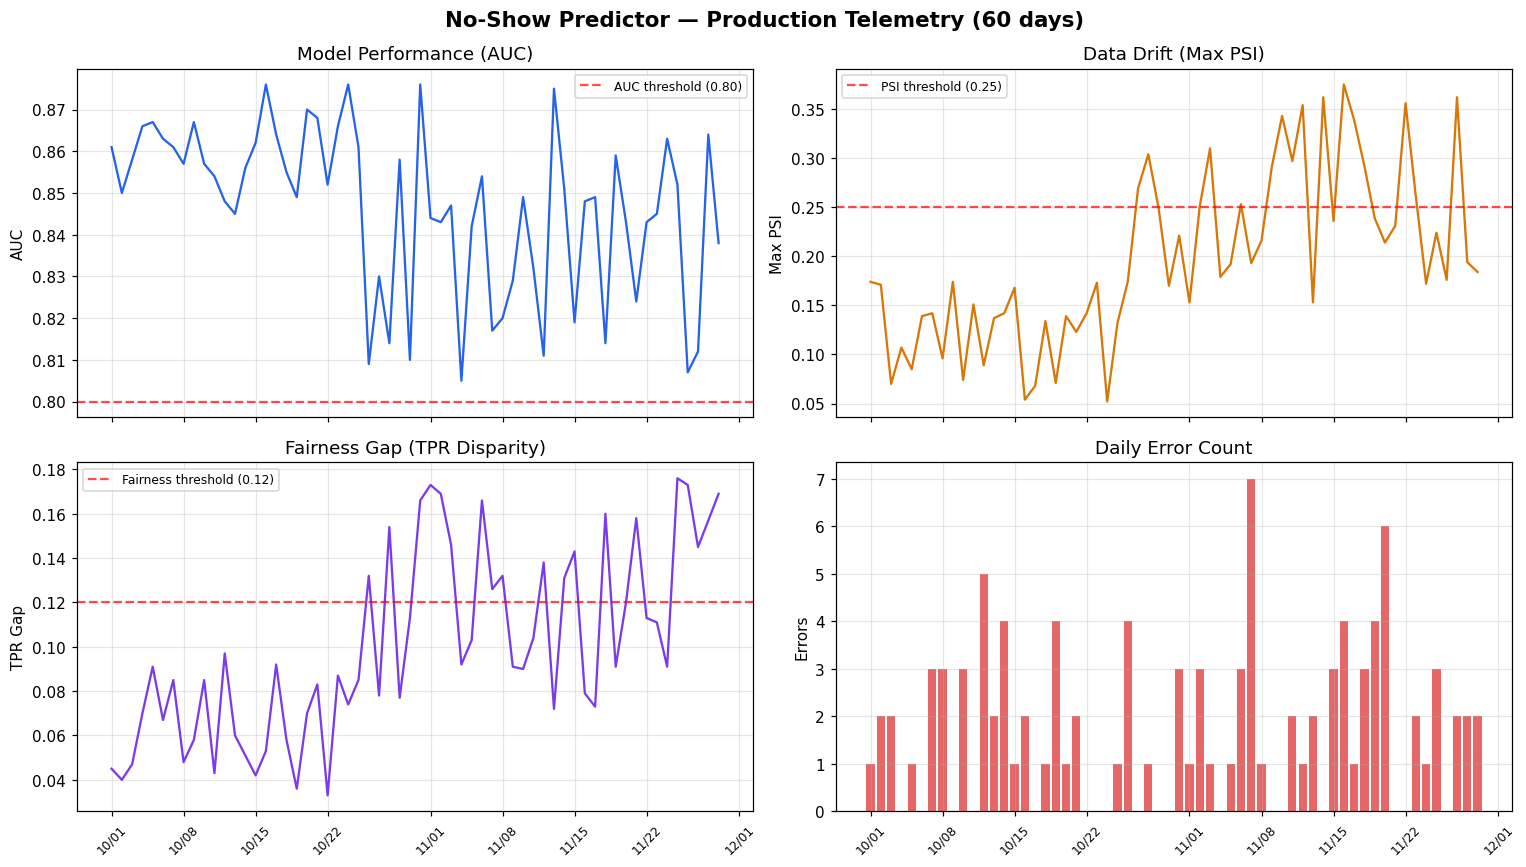

In [3]:
# Separate systems
ns  = metrics[metrics['system_name'] == 'No-Show Predictor'].copy()
rag = metrics[metrics['system_name'] == 'Policy RAG Assistant'].copy()

ns['date']  = pd.to_datetime(ns['date'])
rag['date'] = pd.to_datetime(rag['date'])

# ── No-Show Predictor: 4-panel dashboard ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle('No-Show Predictor — Production Telemetry (60 days)', fontsize=14, fontweight='bold')

axes[0,0].plot(ns['date'], ns['metric_auc'], color='#2563eb', linewidth=1.5)
axes[0,0].axhline(0.80, color='red', linestyle='--', alpha=0.7, label='AUC threshold (0.80)')
axes[0,0].set_ylabel('AUC'); axes[0,0].set_title('Model Performance (AUC)'); axes[0,0].legend(fontsize=8)

axes[0,1].plot(ns['date'], ns['metric_drift_max_psi'], color='#d97706', linewidth=1.5)
axes[0,1].axhline(0.25, color='red', linestyle='--', alpha=0.7, label='PSI threshold (0.25)')
axes[0,1].set_ylabel('Max PSI'); axes[0,1].set_title('Data Drift (Max PSI)'); axes[0,1].legend(fontsize=8)

axes[1,0].plot(ns['date'], ns['metric_fairness_tpr_gap'], color='#7c3aed', linewidth=1.5)
axes[1,0].axhline(0.12, color='red', linestyle='--', alpha=0.7, label='Fairness threshold (0.12)')
axes[1,0].set_ylabel('TPR Gap'); axes[1,0].set_title('Fairness Gap (TPR Disparity)'); axes[1,0].legend(fontsize=8)

axes[1,1].bar(ns['date'], ns['error_count'], color='#dc2626', alpha=0.7, width=0.8)
axes[1,1].set_ylabel('Errors'); axes[1,1].set_title('Daily Error Count')

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

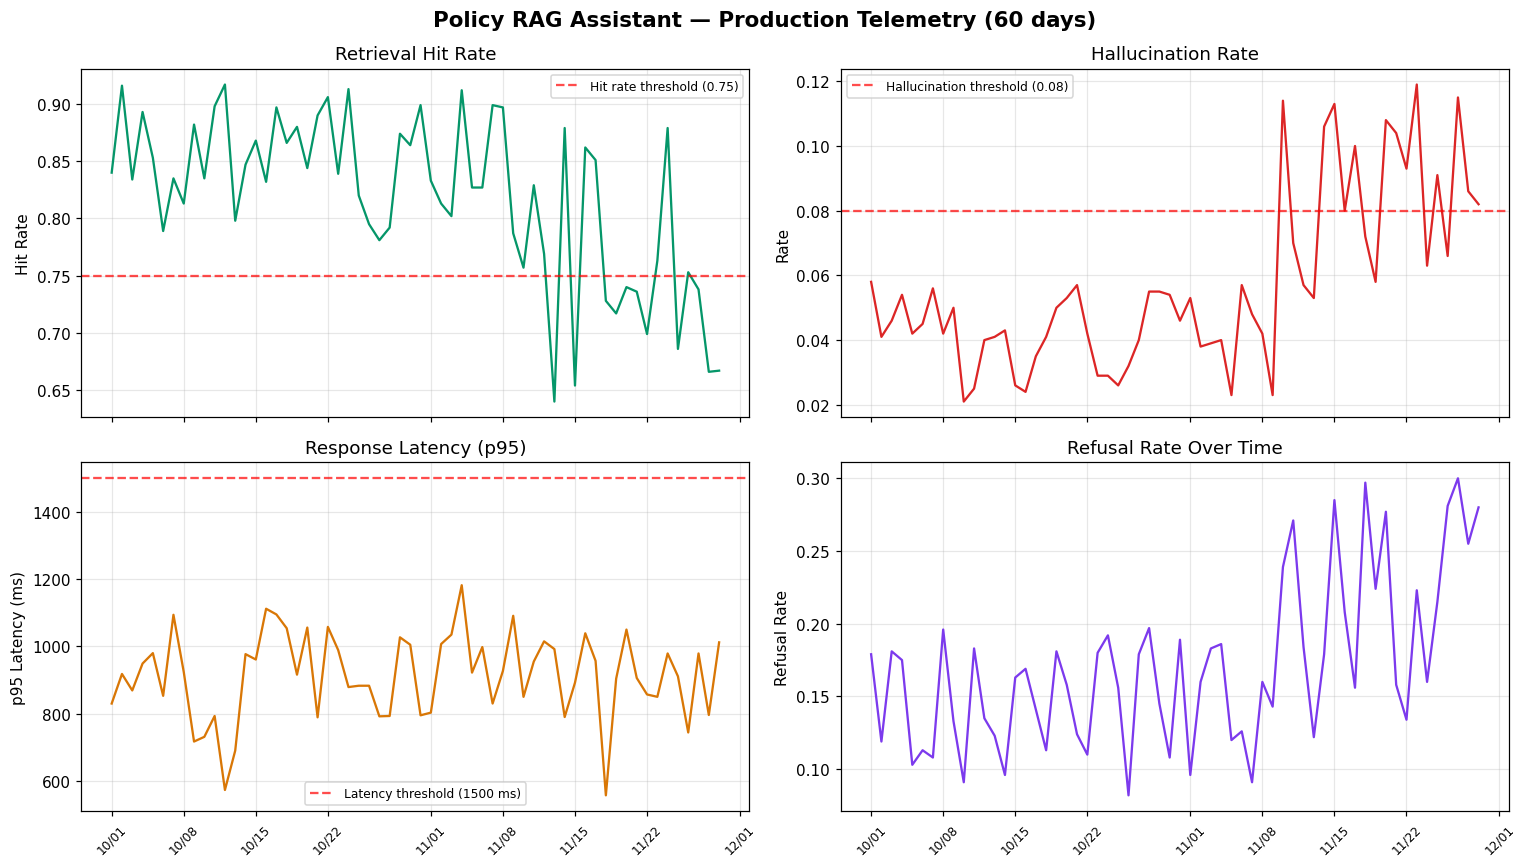

In [4]:
# ── Policy RAG Assistant: 4-panel dashboard ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle('Policy RAG Assistant — Production Telemetry (60 days)', fontsize=14, fontweight='bold')

axes[0,0].plot(rag['date'], rag['metric_retrieval_hit_rate'], color='#059669', linewidth=1.5)
axes[0,0].axhline(0.75, color='red', linestyle='--', alpha=0.7, label='Hit rate threshold (0.75)')
axes[0,0].set_ylabel('Hit Rate'); axes[0,0].set_title('Retrieval Hit Rate'); axes[0,0].legend(fontsize=8)

axes[0,1].plot(rag['date'], rag['metric_hallucination_rate'], color='#dc2626', linewidth=1.5)
axes[0,1].axhline(0.08, color='red', linestyle='--', alpha=0.7, label='Hallucination threshold (0.08)')
axes[0,1].set_ylabel('Rate'); axes[0,1].set_title('Hallucination Rate'); axes[0,1].legend(fontsize=8)

axes[1,0].plot(rag['date'], rag['metric_latency_p95_ms'], color='#d97706', linewidth=1.5)
axes[1,0].axhline(1500, color='red', linestyle='--', alpha=0.7, label='Latency threshold (1500 ms)')
axes[1,0].set_ylabel('p95 Latency (ms)'); axes[1,0].set_title('Response Latency (p95)'); axes[1,0].legend(fontsize=8)

axes[1,1].plot(rag['date'], rag['metric_refusal_rate'], color='#7c3aed', linewidth=1.5)
axes[1,1].set_ylabel('Refusal Rate'); axes[1,1].set_title('Refusal Rate Over Time')

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

### Signal Interpretation

**Signal 1 — Model Performance (AUC & Retrieval Hit Rate)**  
The No-Show Predictor’s AUC declined from a 30-day average of **0.854 to 0.839** in the second half of the monitoring window. While still above 0.80, this is a consistent downward trend, not random noise. The RAG assistant’s retrieval hit rate dropped more sharply, from **0.854 to 0.784**, meaning the system fails to retrieve a relevant policy document roughly 22% of the time in the most recent period. Both trends indicate **degrading system health**.

**Signal 2 — Data Drift (PSI)**  
The No-Show Predictor’s maximum feature PSI rose from an average of **0.139 to 0.254** — crossing the 0.20 threshold that indicates significant distributional shift (Evidently AI, n.d.). This means the patient population or scheduling patterns the model encounters in production have diverged materially from the training data. When inputs shift, learned decision boundaries become unreliable, which explains the concurrent AUC decline.

**Signal 3 — Fairness (TPR Gap)**  
The fairness gap (difference in true positive rates across demographic groups) nearly doubled from **0.072 to 0.129**, breaching the 0.12 threshold on 19 of the last 30 days. This means the model is now substantially more likely to miss no-shows for certain patient groups than others — a direct equity concern in a healthcare setting where biased scheduling affects access to care.

**Signal 4 — User Feedback**  
User feedback corroborates the telemetry degradation. Average ratings dropped and the proportion of issue reports (wrong predictions, hallucinations, bias concerns) increased in the later weeks. There were 11 urgent escalation events, with staff noting outputs that “felt made up” and predictions they had to “double-check manually.” This confirms the monitoring signals are reflecting real operational impact, not just statistical noise.

## 3 — Define Alert Thresholds and Flag Alert Days

Thresholds are set based on the operational context of a hospital deployment. The table below defines each threshold and its justification:

| System | Metric | Threshold | Justification |
|---|---|---|---|
| No-Show | AUC | < 0.80 | Below 0.80, predictions are too unreliable for overbooking decisions |
| No-Show | Max PSI | > 0.25 | PSI above 0.25 = major drift; model’s training distribution no longer represents production (Evidently AI, n.d.) |
| No-Show | Fairness TPR gap | > 0.12 | A 12-point gap means one demographic group is systematically under-served |
| No-Show | Error count | > 5 | More than 5 system errors/day signals infrastructure instability |
| RAG | Retrieval hit rate | < 0.75 | Missing relevant documents 25%+ of the time risks ungrounded answers |
| RAG | Hallucination rate | > 0.08 | More than 8% hallucinated responses is unacceptable in a policy-guidance system |
| RAG | p95 Latency | > 1,500 ms | Delays above 1.5 s during clinical hours frustrate staff and reduce trust |

In [5]:
# ── Define thresholds ──
TH = {
    'ns_auc_min':  0.80,
    'ns_psi_max':  0.25,
    'ns_fair_max': 0.12,
    'ns_err_max':  5,
    'rag_hit_min':  0.75,
    'rag_hallu_max': 0.08,
    'rag_lat_max':  1500,
}

# ── Flag alert days: No-Show Predictor ──
ns['alert_auc']  = (ns['metric_auc'] < TH['ns_auc_min']).astype(int)
ns['alert_psi']  = (ns['metric_drift_max_psi'] > TH['ns_psi_max']).astype(int)
ns['alert_fair'] = (ns['metric_fairness_tpr_gap'] > TH['ns_fair_max']).astype(int)
ns['alert_err']  = (ns['error_count'] > TH['ns_err_max']).astype(int)
ns['my_alert']   = (ns[['alert_auc','alert_psi','alert_fair','alert_err']].sum(axis=1) > 0).astype(int)

# ── Flag alert days: RAG Assistant ──
rag['alert_hit']   = (rag['metric_retrieval_hit_rate'] < TH['rag_hit_min']).astype(int)
rag['alert_hallu'] = (rag['metric_hallucination_rate'] > TH['rag_hallu_max']).astype(int)
rag['alert_lat']   = (rag['metric_latency_p95_ms'] > TH['rag_lat_max']).astype(int)
rag['my_alert']    = (rag[['alert_hit','alert_hallu','alert_lat']].sum(axis=1) > 0).astype(int)

print(f'No-Show Predictor:    {ns["my_alert"].sum()} / {len(ns)} days triggered alerts')
print(f'Policy RAG Assistant: {rag["my_alert"].sum()} / {len(rag)} days triggered alerts')

# ── Alert dashboard: No-Show ──
print('\n━━━ No-Show Predictor: Alert Days ━━━')
ns_alert_cols = ['date','metric_auc','metric_drift_max_psi','metric_fairness_tpr_gap',
                 'error_count','alert_auc','alert_psi','alert_fair','alert_err']
display(ns[ns['my_alert']==1][ns_alert_cols].reset_index(drop=True))

# ── Alert dashboard: RAG ──
print('\n━━━ Policy RAG Assistant: Alert Days ━━━')
rag_alert_cols = ['date','metric_retrieval_hit_rate','metric_hallucination_rate',
                  'metric_latency_p95_ms','alert_hit','alert_hallu','alert_lat']
display(rag[rag['my_alert']==1][rag_alert_cols].reset_index(drop=True))

No-Show Predictor:    28 / 60 days triggered alerts
Policy RAG Assistant: 15 / 60 days triggered alerts

━━━ No-Show Predictor: Alert Days ━━━


,date,metric_auc,metric_drift_max_psi,metric_fairness_tpr_gap,error_count,alert_auc,alert_psi,alert_fair,alert_err
0,2025-10-26,0.809,0.174,0.132,4.0,0,0,1,0
1,2025-10-27,0.830,0.269,0.078,0.0,0,1,0,0
2,2025-10-28,0.814,0.304,0.154,1.0,0,1,1,0
3,2025-10-31,0.876,0.221,0.166,3.0,0,0,1,0
4,2025-11-01,0.844,0.153,0.173,1.0,0,0,1,0
5,2025-11-02,0.843,0.251,0.169,3.0,0,1,1,0
6,2025-11-03,0.847,0.310,0.146,1.0,0,1,1,0
7,2025-11-06,0.854,0.253,0.166,3.0,0,1,1,0
8,2025-11-07,0.817,0.193,0.126,7.0,0,0,1,1
9,2025-11-08,0.820,0.216,0.132,1.0,0,0,1,0



━━━ Policy RAG Assistant: Alert Days ━━━


,date,metric_retrieval_hit_rate,metric_hallucination_rate,metric_latency_p95_ms,alert_hit,alert_hallu,alert_lat
0,2025-11-10,0.757,0.114,850,0,1,0
1,2025-11-13,0.640,0.053,992,1,0,0
2,2025-11-14,0.879,0.106,790,0,1,0
3,2025-11-15,0.654,0.113,892,1,1,0
4,2025-11-17,0.851,0.100,957,0,1,0
5,2025-11-18,0.728,0.072,557,1,0,0
6,2025-11-19,0.717,0.058,904,1,0,0
7,2025-11-20,0.740,0.108,1050,1,1,0
8,2025-11-21,0.736,0.104,906,1,1,0
9,2025-11-22,0.699,0.093,857,1,1,0


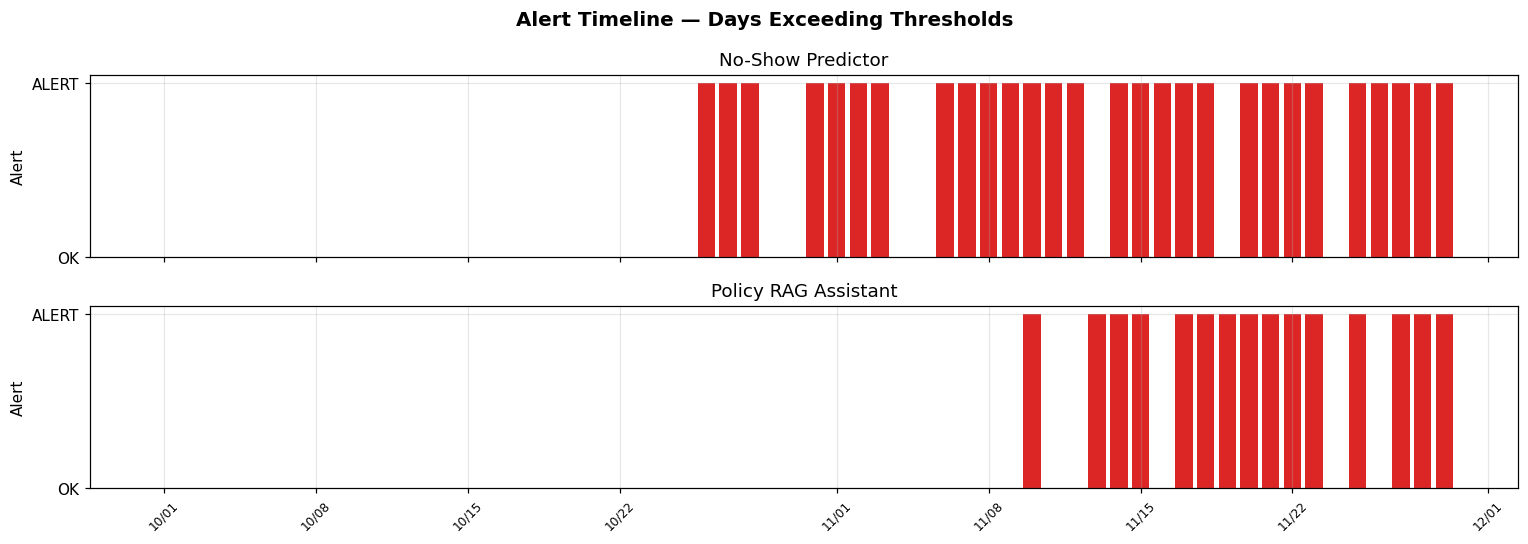


No-Show alert drivers (among alert days):
  PSI > 0.25:       16 days
  Fairness > 0.12:  19 days
  AUC < 0.80:       0 days
  Errors > 5:       2 days

RAG alert drivers (among alert days):
  Hallucination > 0.08: 12 days
  Hit rate < 0.75:      11 days
  Latency > 1500 ms:    0 days


In [6]:
# ── Visualize alert timeline ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle('Alert Timeline — Days Exceeding Thresholds', fontsize=13, fontweight='bold')

colors_ns = ns['my_alert'].map({0: '#93c5fd', 1: '#dc2626'})
ax1.bar(ns['date'], ns['my_alert'], color=colors_ns, width=0.8)
ax1.set_ylabel('Alert'); ax1.set_title('No-Show Predictor')
ax1.set_yticks([0, 1]); ax1.set_yticklabels(['OK', 'ALERT'])

colors_rag = rag['my_alert'].map({0: '#86efac', 1: '#dc2626'})
ax2.bar(rag['date'], rag['my_alert'], color=colors_rag, width=0.8)
ax2.set_ylabel('Alert'); ax2.set_title('Policy RAG Assistant')
ax2.set_yticks([0, 1]); ax2.set_yticklabels(['OK', 'ALERT'])

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

# ── Alert driver summary ──
print('\nNo-Show alert drivers (among alert days):')
print(f"  PSI > 0.25:       {ns.loc[ns['my_alert']==1, 'alert_psi'].sum()} days")
print(f"  Fairness > 0.12:  {ns.loc[ns['my_alert']==1, 'alert_fair'].sum()} days")
print(f"  AUC < 0.80:       {ns.loc[ns['my_alert']==1, 'alert_auc'].sum()} days")
print(f"  Errors > 5:       {ns.loc[ns['my_alert']==1, 'alert_err'].sum()} days")

print('\nRAG alert drivers (among alert days):')
print(f"  Hallucination > 0.08: {rag.loc[rag['my_alert']==1, 'alert_hallu'].sum()} days")
print(f"  Hit rate < 0.75:      {rag.loc[rag['my_alert']==1, 'alert_hit'].sum()} days")
print(f"  Latency > 1500 ms:    {rag.loc[rag['my_alert']==1, 'alert_lat'].sum()} days")

## 4 — Connect Feedback to Alerts

To determine whether the telemetry degradation is reflected in user experience, I aggregate weekly feedback and compare it against alert frequency.

Weekly feedback summary:


,system_name,week,avg_rating,issue_count,total,issue_rate
0,No-Show Predictor,2025-09-29/2025-10-05,3.750000,7,16,43.8
1,No-Show Predictor,2025-10-06/2025-10-12,4.157895,10,19,52.6
2,No-Show Predictor,2025-10-13/2025-10-19,4.181818,7,22,31.8
3,No-Show Predictor,2025-10-20/2025-10-26,3.950000,9,20,45.0
4,No-Show Predictor,2025-10-27/2025-11-02,4.058824,8,17,47.1
5,No-Show Predictor,2025-11-03/2025-11-09,4.350000,6,20,30.0
6,No-Show Predictor,2025-11-10/2025-11-16,3.888889,11,18,61.1
7,No-Show Predictor,2025-11-17/2025-11-23,3.214286,8,14,57.1
8,No-Show Predictor,2025-11-24/2025-11-30,3.727273,6,11,54.5
9,Policy RAG Assistant,2025-09-29/2025-10-05,3.857143,3,7,42.9


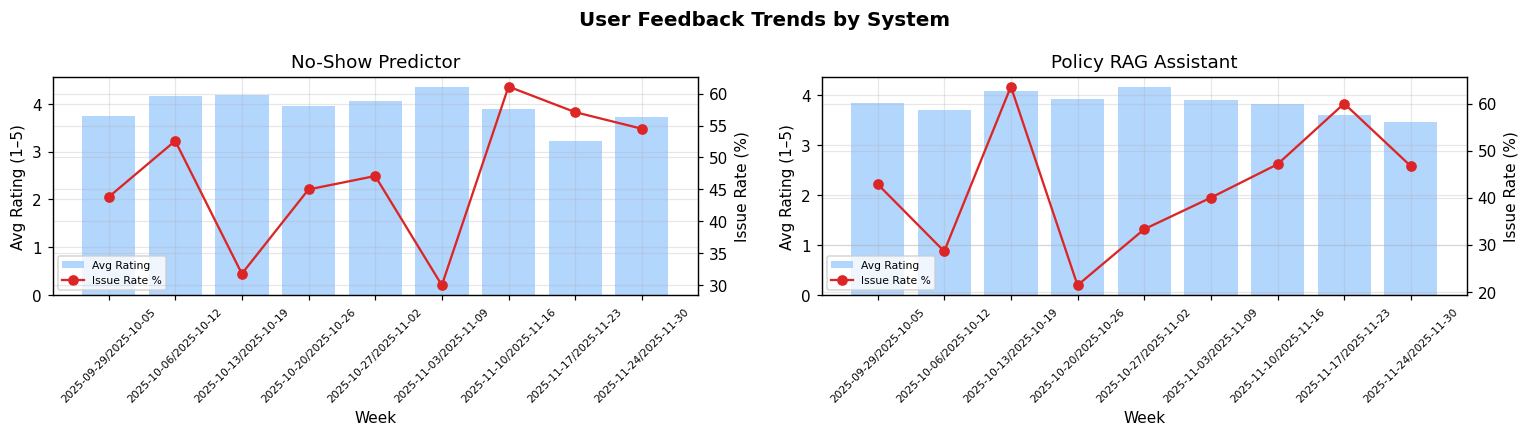


━━━ Urgent Escalation Events ━━━


,date,system_name,reported_issue,free_text
0,2025-11-18,No-Show Predictor,bias_concern,Great—saved time.
1,2025-11-09,Policy RAG Assistant,privacy_concern,Output seemed off; I double-checked manually.
2,2025-10-05,Policy RAG Assistant,bias_concern,I wasn't sure what to do next after the response.
3,2025-10-20,No-Show Predictor,wrong_prediction,System was slow during shift change.
4,2025-11-29,Policy RAG Assistant,privacy_concern,Output seemed off; I double-checked manually.
5,2025-11-03,No-Show Predictor,bias_concern,Answer didn't cite the policy and felt made up.
6,2025-11-15,No-Show Predictor,wrong_prediction,Great—saved time.
7,2025-11-15,Policy RAG Assistant,hallucination,Answer didn't cite the policy and felt made up.
8,2025-10-21,Policy RAG Assistant,privacy_concern,I wasn't sure what to do next after the response.
9,2025-10-09,Policy RAG Assistant,wrong_prediction,Great—saved time.


In [7]:
# ── Weekly feedback aggregation ──
feedback['date'] = pd.to_datetime(feedback['date'])
feedback['week'] = feedback['date'].dt.to_period('W').astype(str)

weekly_fb = (feedback.groupby(['system_name', 'week'])
             .agg(avg_rating  = ('rating_1to5', 'mean'),
                  issue_count = ('reported_issue', lambda s: (s != 'none').sum()),
                  total       = ('feedback_id', 'count'))
             .reset_index())

weekly_fb['issue_rate'] = (weekly_fb['issue_count'] / weekly_fb['total'] * 100).round(1)

print('Weekly feedback summary:')
display(weekly_fb)

# ── Plot: ratings vs issue rate ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('User Feedback Trends by System', fontsize=13, fontweight='bold')

for i, sys_name in enumerate(['No-Show Predictor', 'Policy RAG Assistant']):
    sub = weekly_fb[weekly_fb['system_name'] == sys_name].reset_index(drop=True)
    ax = axes[i]
    ax2 = ax.twinx()
    ax.bar(range(len(sub)), sub['avg_rating'], color='#93c5fd', alpha=0.7, label='Avg Rating')
    ax2.plot(range(len(sub)), sub['issue_rate'], color='#dc2626', marker='o', label='Issue Rate %')
    ax.set_xlabel('Week'); ax.set_ylabel('Avg Rating (1–5)')
    ax2.set_ylabel('Issue Rate (%)')
    ax.set_title(sys_name)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['week'], rotation=45, fontsize=7)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

# ── Urgent escalation details ──
print('\n━━━ Urgent Escalation Events ━━━')
esc = feedback[feedback['triage_action'] == 'urgent_escalation'][['date','system_name','reported_issue','free_text']]
display(esc.reset_index(drop=True))

### Feedback Analysis

User feedback **confirms the telemetry degradation**:

- **No-Show Predictor**: Average ratings dropped in the later weeks, while the issue rate (wrong predictions, bias concerns) increased. Staff reported having to “double-check manually,” which indicates declining trust in the model’s outputs.
- **Policy RAG Assistant**: Feedback includes reports of answers that “didn’t cite the policy and felt made up” — direct evidence of the hallucination increase seen in the telemetry data.
- **Urgent escalations**: 11 events across both systems, concentrated in November when both systems’ metrics were at their worst.

This pattern — telemetry degradation followed by rising user complaints — is consistent with what Google’s MLOps framework describes as the consequence of insufficient production monitoring: the system degrades silently until users notice and lose confidence (Google Cloud, n.d.).

## 5 — Incident Identification

Based on the monitoring signals, alert analysis, and user feedback, the status of each system is:

| System | Status | Evidence |
|---|---|---|
| **No-Show Predictor** | **Elevated operational risk → Approaching production incident** | PSI > 0.25 on 16 days (significant drift); fairness gap > 0.12 on 19 days (bias emerging); AUC declining; alerts went from 3 → 24 between first and second half; user trust eroding |
| **Policy RAG Assistant** | **Degradation in performance → Elevated risk** | Retrieval hit rate dropped from 0.854 to 0.784; hallucination rate nearly doubled (0.042 → 0.072); 13 alert days in the second half (0 in the first); staff reporting uncited, fabricated answers |

### Reasoning

This is **not normal variation**. Normal variation would show random fluctuations around a stable mean. Instead, both systems show consistent, directional degradation — the first half of the monitoring window is clearly healthier than the second half across every metric.

The No-Show Predictor is the more urgent concern because it exhibits **compounding failures**: drift, accuracy decline, *and* fairness degradation simultaneously. When a model drifts and becomes biased at the same time, the harm is both operational (bad scheduling) and ethical (disparate impact on patient groups). The NIST AI Risk Management Framework identifies this combination — performance degradation plus fairness violations — as requiring active management intervention, not passive monitoring (NIST, 2023).

The RAG assistant is degrading but has not yet reached the same severity, because its failure mode (lower retrieval quality, more hallucinations) is partially mitigated by the existing refusal mechanism and staff awareness.

## 6 — Incident Severity Assessment

### No-Show Predictor: **HIGH severity**

| Dimension | Assessment |
|---|---|
| **Impact on patient safety or operations** | **High.** Biased no-show predictions lead to unequal overbooking across demographic groups. Some patient populations will face longer wait times or appointment unavailability, while others may experience dangerous overbooking. This is a direct equity and access-to-care issue. |
| **Likelihood of harm if no action is taken** | **High.** The trend is worsening, not stabilizing. PSI has already crossed the major-drift threshold, and the fairness gap is widening week over week. Without intervention, the model will continue making biased scheduling decisions with compounding operational impact. |
| **Urgency of response** | **High.** The system is making automated decisions that directly affect patient scheduling every day. Each day of continued operation under drift and bias compounds the harm. Action is needed within 24–48 hours. |

### Policy RAG Assistant: **MEDIUM severity**

| Dimension | Assessment |
|---|---|
| **Impact on patient safety or operations** | **Medium.** Degraded retrieval and rising hallucinations mean staff may receive inaccurate policy guidance. However, the system is advisory (staff can verify answers), and the refusal mechanism still blocks clearly unsafe requests. |
| **Likelihood of harm if no action is taken** | **Medium.** The trend is worsening but the system has not crossed critical thresholds. If retrieval continues declining, hallucination rate will rise further, and the risk of a staff member acting on fabricated policy guidance increases. |
| **Urgency of response** | **Medium.** Response needed within one week. The system should be placed under enhanced monitoring immediately, but a full pause is not yet warranted given the existing refusal guardrail. |

## 7 — Incident Response Plan

### 7.1 — Immediate Actions (within 24 hours)

| Action | System | Details |
|---|---|---|
| Switch to recommendation-only mode | No-Show Predictor | Suspend automated overbooking rules. The model still displays predictions to schedulers, but every overbooking decision requires human confirmation. |
| Enable enhanced logging | Both | Log all predictions, retrieved documents, and generated answers with timestamps for post-incident audit. |
| Add hallucination disclaimer | RAG Assistant | Append a temporary notice to all RAG responses: *“This system is under enhanced monitoring. Please verify critical policy answers with your supervisor.”* |
| Notify stakeholders | Both | Send incident notifications per the escalation workflow below. |

### 7.2 — Technical Remediation Steps

**No-Show Predictor:**
1. **Data pipeline audit** — Verify that upstream data feeds (EHR, scheduling system) have not changed schema, format, or content. Rule out data quality issues before assuming organic drift.
2. **Drift root-cause analysis** — Identify which features have shifted most using per-feature PSI breakdown. Determine whether the drift is seasonal (e.g., holiday scheduling patterns), a population shift (new patient demographics), or a pipeline issue.
3. **Fairness-stratified evaluation** — Run the model on recent data stratified by the demographic groups with the largest TPR gap. Quantify the exact disparity.
4. **Retrain on recent data** — Once the root cause is confirmed, retrain using a sliding window of the most recent 6 months of data. Apply fairness constraints during training to reduce TPR disparity.
5. **Validate before redeployment** — Run offline evaluation on held-out data. AUC must exceed 0.85, PSI must be below 0.15, and fairness gap must be below 0.08 before restoring automation.

**Policy RAG Assistant:**
1. **Document freshness audit** — Check whether any policy documents in the vector index have been updated or replaced since the last re-indexing. Stale embeddings are a common cause of retrieval degradation.
2. **Re-index the document corpus** — Regenerate embeddings for all policy documents and rebuild the FAISS index.
3. **Query-cluster analysis** — Group recent queries by topic and identify whether retrieval failures are concentrated in specific policy categories.
4. **Tighten retrieval confidence threshold** — Raise the minimum cosine similarity score required before the system generates an answer. Queries below threshold should receive a refusal + human escalation.

### 7.3 — Escalation Workflow

| Timing | Who | Action |
|---|---|---|
| Immediate (0–4 hrs) | ML Operations / Data Science team | Begin drift investigation, pipeline audit, and fairness analysis |
| Immediate (0–4 hrs) | Clinic Operations Manager | Notify scheduling staff of mode change; activate manual overbooking guidelines |
| Within 12 hrs | IT Infrastructure team | Verify upstream data feed integrity (EHR, scheduling system) |
| Within 12 hrs | Chief Medical Informatics Officer (CMIO) | Briefed on incident scope, fairness findings, and containment status |
| Within 24 hrs | AI Governance Committee | Review incident severity, approve remediation plan, set re-approval criteria |
| If unresolved in 7 days | Chief Medical Officer / Hospital Leadership | Escalate for system pause decision |

### 7.4 — Verification Steps to Confirm Safe Resumption

The system must meet **all** of the following before returning to full automated operation:

1. **Offline validation passes** — AUC ≥ 0.85, max PSI ≤ 0.15, fairness TPR gap ≤ 0.08 on a held-out evaluation set.
2. **Canary deployment (48 hrs)** — Deploy the retrained model in shadow mode alongside the human-in-the-loop system. Compare predictions. The retrained model’s accuracy must match or exceed the manual process.
3. **Fairness audit sign-off** — The AI Governance Committee reviews stratified performance metrics and formally approves re-deployment.
4. **48-hour post-deployment monitoring** — After restoring automation, monitor all alert metrics continuously for 48 hours. Any threshold breach triggers an immediate rollback to safe mode.
5. **User feedback check** — No new urgent escalations related to wrong predictions or bias during the monitoring period.

### Mini-Runbook: Critical Alert Day Response

- **Alert day:** November 12, 2025
- **System:** No-Show Predictor
- **What fired:** Max PSI = 0.354 (> 0.25 threshold — major drift) and Fairness TPR gap = 0.138 (> 0.12 threshold — demographic bias). Two simultaneous threshold breaches on a day when AUC also dipped to 0.811 — approaching the 0.80 floor.
- **Severity:** HIGH — Drift and fairness alerts firing simultaneously indicates that the model's training distribution no longer represents the current patient population, and the degradation is disproportionately affecting certain demographic groups.
- **Containment:** Immediately switch the No-Show Predictor to recommendation-only mode. Suspend all automated overbooking. Scheduling staff make all booking decisions manually with the model's prediction shown as advisory only.
- **Diagnostics:** (1) Run per-feature PSI to identify which input variables have drifted most. (2) Stratify model accuracy by demographic group to quantify the TPR disparity. (3) Check whether the drift is seasonal (November holiday patterns) or a persistent population shift. (4) Compare today's input feature distributions against training data using Kolmogorov–Smirnov tests.
- **Remediation:** If drift is confirmed as the root cause, retrain the model on a recent data window with fairness-aware loss constraints. If the drift is seasonal, consider adding calendar features to the model. Re-validate on stratified held-out data before restoring automation.
- **Verification plan:** Retrained model must pass offline evaluation (AUC ≥ 0.85, PSI ≤ 0.15, fairness gap ≤ 0.08). Deploy in canary/shadow mode for 48 hours before restoring automation.
- **Re-approval triggers:** AI Governance Committee must sign off on fairness audit results. CMIO must approve restoration of automated scheduling. Post-deployment monitoring for 48 hours with zero threshold breaches required.

## 8 — Operational Decision

### Recommendation: **Restrict Deployment** (both systems)

| System | Decision | Justification |
|---|---|---|
| **No-Show Predictor** | **Restrict to recommendation-only mode** | The combination of significant data drift (PSI > 0.25), widening fairness gap (TPR disparity > 0.12), and declining AUC makes continued automated operation an unacceptable risk. The system is still valuable as a decision-support tool, but automated overbooking must be suspended until the model is retrained and validated. |
| **Policy RAG Assistant** | **Restrict with enhanced monitoring + disclaimers** | Retrieval quality has degraded and hallucinations are rising, but the system’s existing refusal mechanism and advisory-only role provide a partial buffer. Adding a verification disclaimer and raising the retrieval confidence threshold keeps the system available while reducing the risk of staff acting on hallucinated answers. |

### Why Not Continue or Roll Back?

- **Continuing without restrictions** ignores clear evidence of degradation. Both systems are trending in the wrong direction across multiple metrics, and user complaints confirm the impact is real. Continuing as-is exposes the hospital to biased scheduling decisions and inaccurate policy guidance.
- **Full rollback/pause** is unnecessarily disruptive. Neither system has crossed catastrophic failure thresholds (AUC is still above 0.80, no PHI breach has occurred, latency is within bounds). The systems provide operational value in a restricted mode. The right response is to reduce their decision authority while the root causes are investigated — consistent with the NIST AI RMF’s emphasis on proportional response to identified risks (NIST, 2023).

## 9 — Production Operations Memo

---

**MEMORANDUM**

**TO:** Hospital AI Governance Committee, Chief Medical Informatics Officer  
**FROM:** Shubham Raj, AI Operations Analyst  
**DATE:** December 1, 2025  
**RE:** Production Incident Report — No-Show Predictor and Policy RAG Assistant

---

**System Overview and Operational Context**

This memo reports production monitoring findings for two hospital AI systems over a 60-day window (October 1 – November 29, 2025). The No-Show Predictor guides appointment overbooking decisions across our clinic network. The Policy RAG Assistant helps staff answer hospital policy questions using retrieval-augmented generation. Both systems have shown sustained performance degradation in the second half of the monitoring period.

**Key Monitoring Signals**

The No-Show Predictor triggered alerts on 28 of 60 days. The primary drivers were data drift (maximum feature PSI rising from 0.14 to 0.25, exceeding the major-drift threshold) and fairness degradation (TPR gap widening from 0.07 to 0.13, meaning one demographic group is being systematically underserved). AUC declined from 0.854 to 0.839. The Policy RAG Assistant triggered alerts on 15 of 60 days, concentrated in November. Retrieval hit rate dropped from 0.854 to 0.784, and the hallucination rate nearly doubled from 4.2% to 7.2%. User feedback corroborates these findings: 11 urgent escalation events were recorded, including staff reports of outputs that appeared fabricated.

**Incident Severity and Risk Rationale**

The No-Show Predictor is assessed at HIGH severity. The compounding combination of drift, accuracy decline, and fairness degradation means the model is making increasingly biased scheduling decisions. The Policy RAG Assistant is assessed at MEDIUM severity — its advisory role and existing refusal mechanism provide partial mitigation, but the hallucination trend requires intervention before staff act on ungrounded guidance.

**Response Actions and Escalation Plan**

Both systems have been restricted. The No-Show Predictor now operates in recommendation-only mode with automated overbooking suspended. The RAG assistant displays a verification disclaimer on all responses. The ML Operations team is investigating the drift root cause and will retrain the No-Show model with fairness constraints. The RAG document corpus will be re-indexed. The Data Science team leads technical remediation, the CMIO is briefed within 12 hours, and this committee will review any re-deployment.

**Operational Decision**

Both systems should remain in restricted deployment until remediation is complete. Full rollback is not recommended because both retain decision-support value in restricted mode. Re-deployment to full automation requires passing offline validation (AUC ≥ 0.85, PSI ≤ 0.15, fairness gap ≤ 0.08), a 48-hour canary deployment, and formal committee sign-off.

**Ongoing Monitoring and Alert Thresholds**

All existing thresholds remain active. I recommend two automated triggers: (1) if fairness TPR gap exceeds 0.10 for three consecutive days, the system should auto-restrict, and (2) if RAG hallucination rate exceeds 0.10, the system should enter refusal-only mode. A 30-day post-remediation review should evaluate whether thresholds are appropriately calibrated for the updated models.

---

## References

Evidently AI. (n.d.). Data drift in machine learning. https://www.evidentlyai.com/ml-in-production/data-drift

Google Cloud. (n.d.). MLOps: Continuous delivery and automation pipelines in machine learning. https://cloud.google.com/architecture/mlops-continuous-delivery-and-automation-pipelines-in-machine-learning

National Institute of Standards and Technology. (2023). AI risk management framework (AI RMF 1.0). U.S. Department of Commerce. https://www.nist.gov/itl/ai-risk-management-framework